## Lorenz-63 System


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

In [30]:
def lorenz_system(state, sigma=10.0, rho=28.0, beta=8/3):
    x, y, z = state
    
    dx_dt = sigma * (y - x)
    dy_dt = x * (rho - z) - y
    dz_dt = x * y - beta * z
    
    return np.array([dx_dt, dy_dt, dz_dt])

In [31]:
def rk4_step(state, dt):
    k1 = lorenz_system(state)
    k2 = lorenz_system(state + (dt / 2) * k1)
    k3 = lorenz_system(state + (dt / 2) * k2)
    k4 = lorenz_system(state + dt * k3)
    
    return state + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

In [32]:
dt = 2.5e-2
total_steps = int(1e6)

In [33]:
current_state = np.array([1.0, 1.0, 1.0])
trajectory = []

In [34]:
for i in range(total_steps):
    trajectory.append(current_state)
    current_state = rk4_step(current_state, dt)

# Convert to a numpy array for easy handling
trajectory = np.array(trajectory)

print(f"Generated data shape: {trajectory.shape}")

Generated data shape: (1000000, 3)


In [35]:
trajectory[:5,:]

array([[1.        , 1.        , 1.        ],
       [1.07545053, 1.65930813, 0.96861164],
       [1.2876899 , 2.39988521, 0.96379682],
       [1.63448705, 3.30797486, 1.00201622],
       [2.13310847, 4.47105098, 1.11389662]])

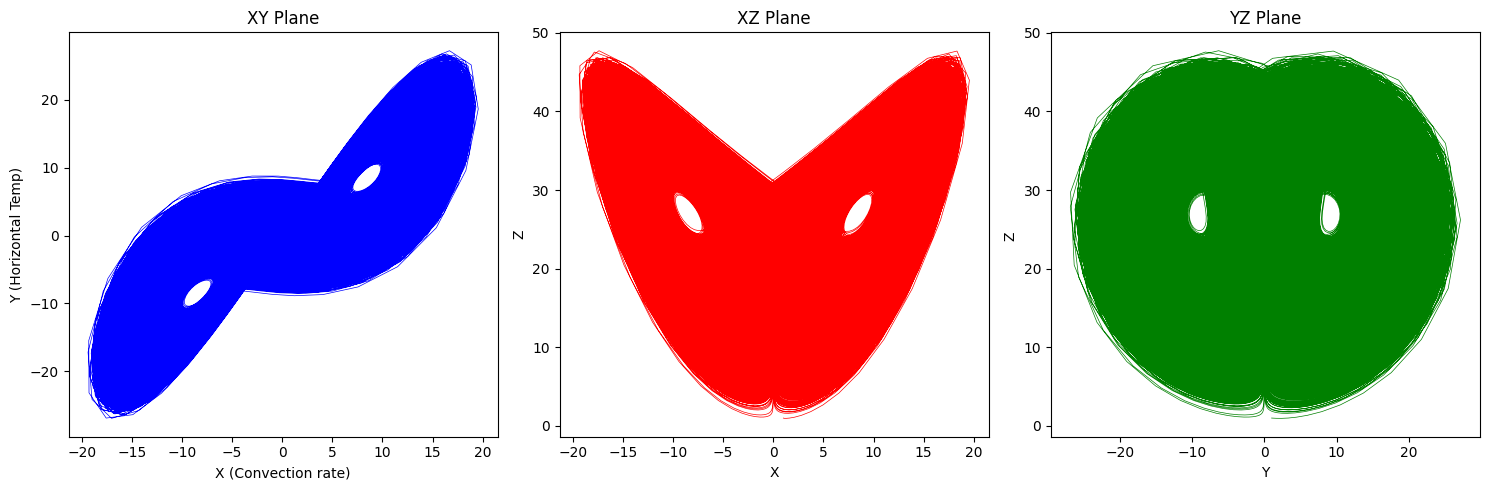

In [36]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.plot(trajectory[:, 0], trajectory[:, 1], color='blue', lw=0.5)
ax1.set_xlabel('X (Convection rate)')
ax1.set_ylabel('Y (Horizontal Temp)')
ax1.set_title('XY Plane')


ax2.plot(trajectory[:, 0], trajectory[:, 2], color='red', lw=0.5)
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
ax2.set_title('XZ Plane')


ax3.plot(trajectory[:, 1], trajectory[:, 2], color='green', lw=0.5)
ax3.set_xlabel('Y')
ax3.set_ylabel('Z ')
ax3.set_title('YZ Plane')

plt.tight_layout()
plt.show()

In [37]:
def create_joint_windows(trajectory, n=2):
    total_steps = len(trajectory)
    num_possible_windows = total_steps - (n - 1)
    windows = []
    for i in range(num_possible_windows):
        window_segment = trajectory[i : i + n]
        flat_vector = window_segment.flatten()
        windows.append(flat_vector)

    return np.array(windows)

In [38]:
time_windows = create_joint_windows(trajectory)
print(f"Time window data shape: {time_windows.shape}")

Time window data shape: (999999, 6)


In [39]:
print(time_windows[:5,:])

[[1.         1.         1.         1.07545053 1.65930813 0.96861164]
 [1.07545053 1.65930813 0.96861164 1.2876899  2.39988521 0.96379682]
 [1.2876899  2.39988521 0.96379682 1.63448705 3.30797486 1.00201622]
 [1.63448705 3.30797486 1.00201622 2.13310847 4.47105098 1.11389662]
 [2.13310847 4.47105098 1.11389662 2.81735656 5.98633224 1.35396999]]


In [ ]:
train_dataset = time_windows[:]

In [ ]:
print(f'Number of time windows (samples) in the Training Dataset = {len(train_dataset)}')

Number of time windows (samples) in the Training Dataset = 999999


In [46]:
class customDataset(Dataset):
    def __init__(self,x):
        self.features = torch.tensor(x,dtype = torch.float32)
    
    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self,index):
        return self.features[index,:]

In [47]:
train_dataset = customDataset(train_dataset)
train_dataloader = DataLoader(train_dataset,batch_size = 200, shuffle=True)

In [54]:
class ContinuousNADE(nn.Module):
    def __init__(self,input_dim = 6, hidden_dim = 500):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        self.W = nn.Parameter(torch.randn(hidden_dim, input_dim) * 0.1)
        self.c = nn.Parameter(torch.zeros(hidden_dim))

        self.V_mu = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.1)
        self.b_mu = nn.Parameter(torch.zeros(input_dim))

        self.V_log_sigma = nn.Parameter(torch.randn(input_dim, hidden_dim) * 0.1)
        self.b_log_sigma = nn.Parameter(torch.zeros(input_dim))

    def forward(self,x):
        batch_size = x.shape[0]

        mu_outputs = torch.zeros_like(x)
        log_sigma_outputs = torch.zeros_like(x)

        a_i = self.c.repeat(batch_size,1)

        for i in range(self.input_dim):
            h_i = torch.relu(a_i)
            mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
            log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

            mu_outputs[:, i] = mu_i
            log_sigma_outputs[:, i] = log_sigma_i

            if i < self.input_dim - 1:
                v_i = x[:, i].unsqueeze(1)
                W_i = self.W[:, i].unsqueeze(0)
                a_i = a_i + v_i * W_i

        return mu_outputs, log_sigma_outputs

    def sample(self):
        generated_sequence = torch.zeros(self.input_dim)
        a_i = self.c.clone()

        with torch.no_grad():
            for i in range(self.input_dim):
                h_i = torch.relu(a_i)
                mu_i = h_i @ self.V_mu[i] + self.b_mu[i]
                log_sigma_i = h_i @ self.V_log_sigma[i] + self.b_log_sigma[i]

                sigma_i = torch.exp(log_sigma_i)
                sampled_value = mu_i + sigma_i * torch.randn(1)
                generated_sequence[i] = sampled_value
                if i < self.input_dim - 1:
                    a_i = a_i + self.W[:, i] * sampled_value

        return generated_sequence

In [55]:
def gaussian_nll_loss(mu, log_sigma, target):

    variance = torch.exp(log_sigma) ** 2
    

    loss = 0.5 * ((target - mu) ** 2 / variance) + log_sigma + 0.5 * np.log(2 * np.pi)
    
    # Sum across the 6 dimensions, then get the mean for the batch
    return loss.sum(dim=1).mean()

In [56]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ContinuousNADE(input_dim=6, hidden_dim=500).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001) # Adam usually works better here than SGD

epochs = 50

# Simple Training Loop
for epoch in range(epochs):
    train_loss = 0.0
    model.train()
    
    for batch in train_dataloader:
        batch = batch.to(device)
        
        optimizer.zero_grad()
        
        # Model now returns two things
        mu_outputs, log_sigma_outputs = model(batch)
        
        # Calculate loss
        loss = gaussian_nll_loss(mu_outputs, log_sigma_outputs, batch)
        
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        
    avg_loss = train_loss / len(train_dataloader)
    print(f'Epoch {epoch+1}/{epochs} | Avg Train Loss: {avg_loss:.4f}')

Epoch 1/50 | Avg Train Loss: 18140.1132
Epoch 2/50 | Avg Train Loss: 8.1225


KeyboardInterrupt: 